Dataset Sample:

   Income  CreditScore  Age  LoanAmount  EmploymentYears  Approved
0   35795          645   46       30826                1         0
1   20860          782   43       35354               12         0
2   96820          729   29       18843               13         1
3   74886          662   32       49472               23         1
4   26265          601   21       11190               18         0

Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0

Confusion Matrix (Random Forest):
[[17  0]
 [ 0 23]]


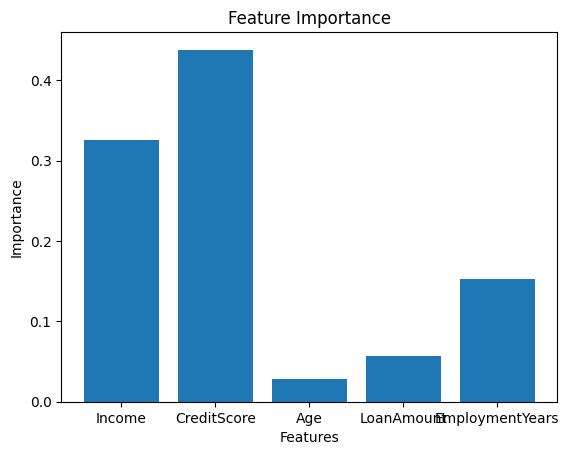


Model saved as loan_model.pkl

Prediction for new customer (1=Approved,0=Rejected): 1


In [2]:
# Loan Approval Predictor (Improved Version)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
np.random.seed(42)

n = 200
data = {
    "Income": np.random.randint(20000, 120000, n),
    "CreditScore": np.random.randint(550, 850, n),
    "Age": np.random.randint(21, 60, n),
    "LoanAmount": np.random.randint(5000, 50000, n),
    "EmploymentYears": np.random.randint(0, 25, n)
}

df = pd.DataFrame(data)

df["Approved"] = (
    (df["CreditScore"] > 650) &
    (df["Income"] > 40000) &
    (df["EmploymentYears"] > 2)
).astype(int)

print("Dataset Sample:\n")
print(df.head())

X = df.drop("Approved", axis=1)
y = df["Approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("\nDecision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)
print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_test, rf_pred))

importance = rf.feature_importances_

plt.figure()
plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

with open("loan_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("\nModel saved as loan_model.pkl")

new_customer = pd.DataFrame({
    "Income": [60000],
    "CreditScore": [720],
    "Age": [35],
    "LoanAmount": [20000],
    "EmploymentYears": [6]
})
prediction = rf.predict(new_customer)
print("\nPrediction for new customer (1=Approved,0=Rejected):", prediction[0])